# Predicting State-wise EV Adoption  
## Notebook 01: Data Understanding

### Purpose
This notebook focuses on understanding the structure, meaning, and quality of the raw EV adoption dataset before performing any cleaning, transformation, or modeling.

The goal is to validate data consistency, inspect feature distributions, and identify potential structural issues such as redundancy, imbalance, or leakage.


### Column Overview

- **country**: The political identity of the location (25 countries).
- **region**: Broader classification of the location (5 regions).
- **year**: Observation year (2010-2025).
- **vehicle_segment**: Vehicle market segment (Commercial, Mass Market, Premium).
- **powertrain_type**: Label indicating ICE or BEV (note: but only offers redundant data and has no value to row data).
- **ev_sales**: Number of EVs sold (units).
- **petrol_sales**: Number of petrol vehicles sold (units).
- **diesel_sales**: Number of diesel vehicles sold (units).
- **total_vehicle_sales**: Total vehicles sold (units).
- **ev_market_share**: Percentage of EV sales relative to total sales (%).
- **charging_stations**: Number of EV charging stations.
- **fast_chargers_share**: Percentage of charging stations that are fast chargers.
- **avg_ev_range_km**: Average driving range of EVs.
- **fuel_price_usd_per_liter**: Fuel cost (USD per liter).
- **electricity_price_usd_per_kwh**: Electricity price for EV charging.
- **gdp_per_capita**: Economic indicator (USD per person).
- **urban_population_percent**: Percentage of population living in urban areas.
- **co2_emissions_transport_mt**: Transport sector CO₂ emissions (metric tonnes).
- **ev_subsidy_usd**: Government EV subsidy amount (USD).
- **emission_regulation_score**: Policy strictness index (0–100 scale).
- **ev_growth_rate_yoy**: Year-over-Year growth rate of EV sales.
- **is_ev_dominant**: Binary classification target (1 if EV market share > 50%).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the raw EV dataset
df = pd.read_csv("../Data/ev_vs_petrol_dataset_v3.csv")

# display first 5 rows
df.head()

,country,region,year,vehicle_segment,powertrain_type,ev_sales,petrol_car_sales,diesel_car_sales,total_vehicle_sales,ev_market_share,...,avg_ev_range_km,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
0,Australia,Oceania,2010,commercial,ICE,5,92877,61921,154803,0.00,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
1,Australia,Oceania,2010,mass_market,ICE,57,535933,73089,609079,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
2,Australia,Oceania,2010,premium,ICE,37,235282,20462,255781,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
3,Australia,Oceania,2011,commercial,ICE,11,98092,65395,163498,0.01,...,133,1.09,0.163,52807,88.9,88.3,0,30.8,120.00,0
4,Australia,Oceania,2011,mass_market,ICE,129,569679,77684,647492,0.02,...,133,1.09,0.163,52807,88.9,88.3,0,30.8,126.32,0


In [3]:
# (total rows, total columns)
df.shape

(1200, 22)

In [4]:
# data type and none-null count for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country                        1200 non-null   object 
 1   region                         1200 non-null   object 
 2   year                           1200 non-null   int64  
 3   vehicle_segment                1200 non-null   object 
 4   powertrain_type                1200 non-null   object 
 5   ev_sales                       1200 non-null   int64  
 6   petrol_car_sales               1200 non-null   int64  
 7   diesel_car_sales               1200 non-null   int64  
 8   total_vehicle_sales            1200 non-null   int64  
 9   ev_market_share                1200 non-null   float64
 10  charging_stations              1200 non-null   int64  
 11  fast_chargers_share            1200 non-null   float64
 12  avg_ev_range_km                1200 non-null   i

In [5]:
# total nulls present in each column
df.isna().sum()

country                          0
region                           0
year                             0
vehicle_segment                  0
powertrain_type                  0
ev_sales                         0
petrol_car_sales                 0
diesel_car_sales                 0
total_vehicle_sales              0
ev_market_share                  0
charging_stations                0
fast_chargers_share              0
avg_ev_range_km                  0
fuel_price_usd_per_liter         0
electricity_price_usd_per_kwh    0
gdp_per_capita                   0
urban_population_percent         0
co2_emissions_transport_mt       0
ev_subsidy_usd                   0
emission_regulation_score        0
ev_growth_rate_yoy               0
is_ev_dominant                   0
dtype: int64

In [6]:
# check for duplicate rows in the dataset
df.duplicated().sum()

0

In [7]:
# general statistic information of the datafile
df.describe()

,year,ev_sales,petrol_car_sales,diesel_car_sales,total_vehicle_sales,ev_market_share,charging_stations,fast_chargers_share,avg_ev_range_km,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
count,1200.000000,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03,1200.000000,1.200000e+03,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2017.500000,6.360236e+04,7.733063e+05,1.409369e+05,9.778455e+05,6.327992,5.693898e+04,14.437750,265.872500,1.342239,0.169508,35651.525000,74.609000,190.837000,2910.940000,58.761860,64.002958,0.018333
std,4.611694,4.079506e+05,1.756934e+06,2.913472e+05,2.211799e+06,13.231723,3.359383e+05,10.057529,121.994051,0.363461,0.079298,23899.013679,14.858811,363.100639,2477.306742,20.092871,71.386797,0.134210
min,2010.000000,5.000000e+00,1.727000e+03,1.500000e+02,1.748000e+04,0.000000,0.000000e+00,0.000000,106.000000,0.482900,0.066990,1359.000000,30.900000,5.400000,0.000000,19.484000,-40.960000,0.000000
25%,2013.750000,2.002500e+02,8.870500e+04,1.951075e+04,1.300465e+05,0.077500,4.917500e+02,6.000000,150.000000,1.097000,0.098750,11077.250000,64.175000,30.175000,0.000000,43.600000,16.372500,0.000000
50%,2017.500000,2.731500e+03,2.294785e+05,5.136100e+04,2.905130e+05,0.830000,4.090000e+03,12.900000,238.500000,1.352000,0.158000,37329.000000,79.900000,94.250000,2794.500000,59.350000,44.165000,0.000000
75%,2021.250000,1.990500e+04,6.385320e+05,1.111910e+05,7.624482e+05,5.832500,2.251800e+04,20.950000,380.250000,1.568500,0.220250,50930.000000,84.075000,159.575000,4973.750000,74.825000,80.907500,0.000000
max,2025.000000,7.670056e+06,1.477369e+07,2.014595e+06,1.884998e+07,95.000000,4.338106e+06,49.300000,507.000000,2.153000,0.379040,103437.000000,98.500000,1900.800000,8952.000000,95.602000,300.000000,1.000000


In [8]:
# sorting the order of dataset
df = df.sort_values(by=["country", "vehicle_segment", "year"]).reset_index(drop=True)

In [9]:
# validate total sales consistency
(df["petrol_car_sales"] + df["diesel_car_sales"] + df["ev_sales"] 
 == df["total_vehicle_sales"]).all()

True

In [10]:
# validate market share calculation
calculated_share = (df["ev_sales"] / df["total_vehicle_sales"]) * 100
(calculated_share - df["ev_market_share"]).describe()

count    1200.000000
mean        0.000249
std         0.002465
min        -0.004994
25%        -0.000948
50%         0.000007
75%         0.001894
max         0.004999
dtype: float64

In [11]:
# classification targets analysis
df["is_ev_dominant"].value_counts(normalize=True)

0    0.981667
1    0.018333
Name: is_ev_dominant, dtype: float64

Observation:
The binary target variable shows **class imbalance**, with EV dominance being less frequent. 
This reflects realistic adoption trends and will be handled using appropriate evaluation metrics.


In [12]:
# regression targets analysis
df["ev_market_share"].describe()

count    1200.000000
mean        6.327992
std        13.231723
min         0.000000
25%         0.077500
50%         0.830000
75%         5.832500
max        95.000000
Name: ev_market_share, dtype: float64

Observation:
Most countries have low EV market share, but a few have very high adoption, which makes the data **highly right skewed**.

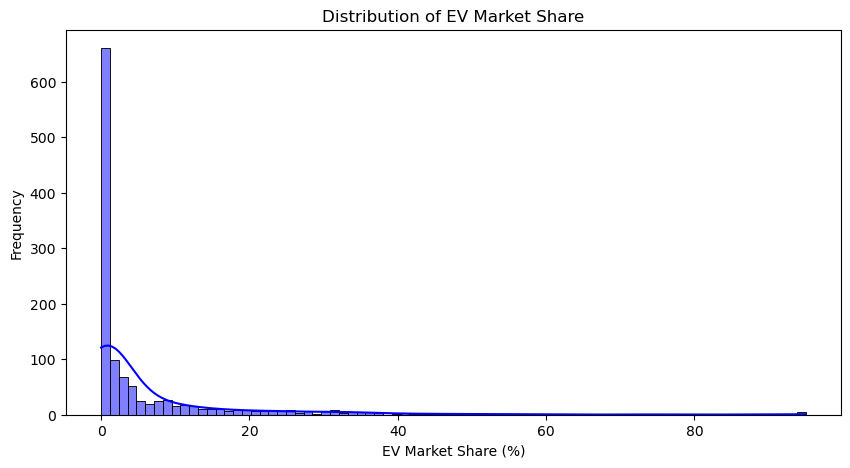

In [13]:
# visualize the right-skewness of EV Market Share
plt.figure(figsize=(10, 5))
sns.histplot(df['ev_market_share'], bins=80, kde=True, color='blue')
plt.title('Distribution of EV Market Share')
plt.xlabel('EV Market Share (%)')
plt.ylabel('Frequency')
plt.show()

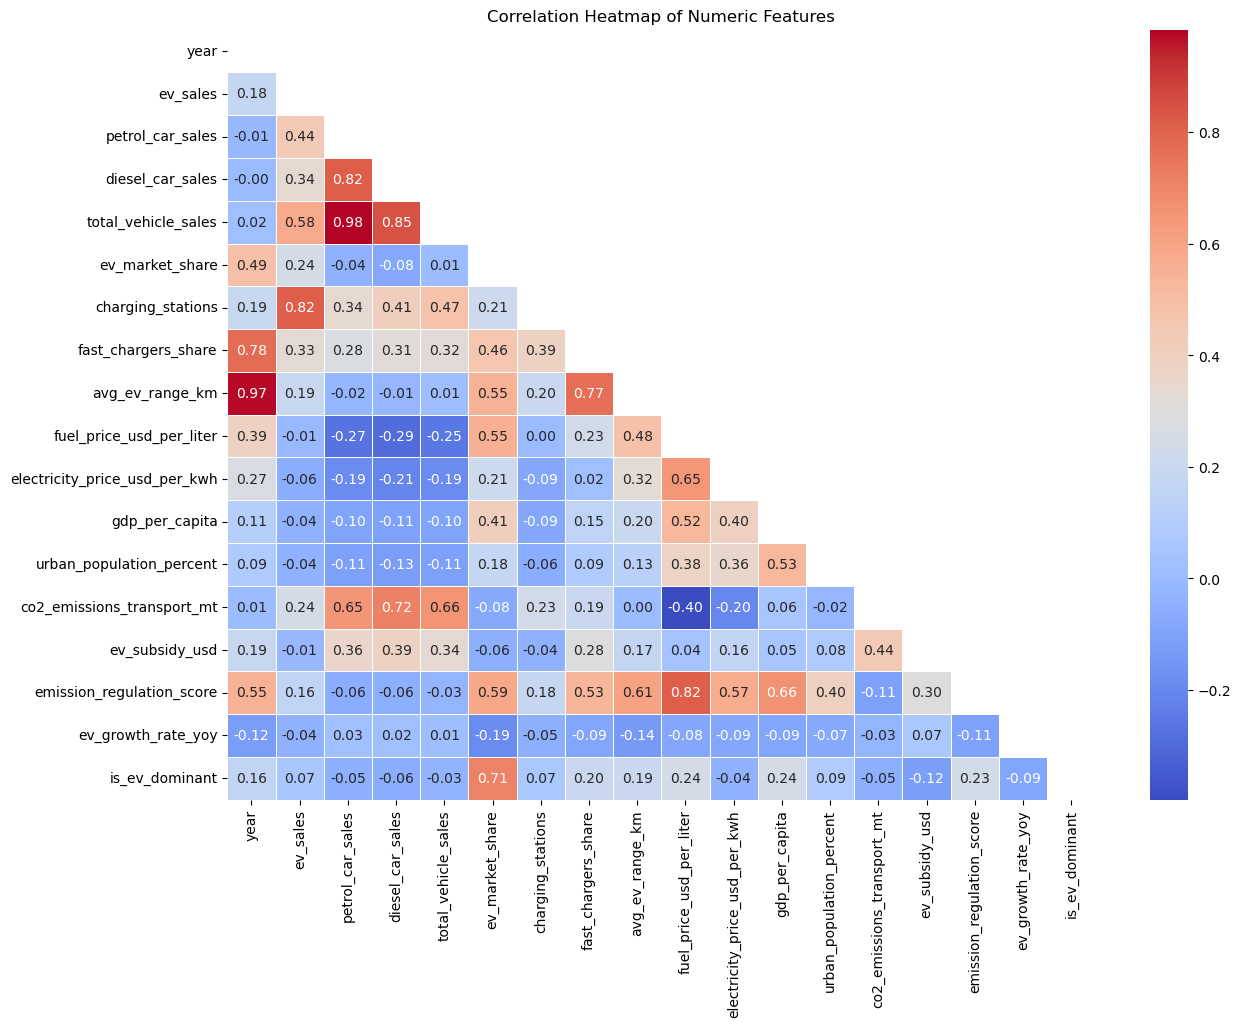

In [14]:
# plot a correlation heatmap for numerical variables
plt.figure(figsize=(14, 10))
corr_matrix = df.corr(numeric_only=True)

# use a mask to only show the lower triangle for cleaner viewing
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


Note: Logically, `ev_market_share`, `ev_growth_rate_yoy`, and `is_ev_dominant` are most likely to cause data leakage. However, all of the mentioned don't cause it from the correlation analysis. There are 2 new scenarios of multicollinearity: `avg_ev_range_km` and `year`, `petrol_car_sales` and `total_vehicle_sales`.

In [15]:
# countries and their number
# countries and their number
print(f"Total number of countries: {df['country'].nunique()}")
print(f"Unique countries: {df['country'].unique()}")

Total number of countries: 25
Unique countries: ['Australia' 'Austria' 'Belgium' 'Brazil' 'Canada' 'China' 'France'
 'Germany' 'India' 'Indonesia' 'Italy' 'Japan' 'Mexico' 'Netherlands'
 'Norway' 'Poland' 'Portugal' 'South Korea' 'Spain' 'Sweden' 'Switzerland'
 'Thailand' 'Turkey' 'United Kingdom' 'United States']


In [16]:
# regions and their number
print(f"Total number of regions: {df['region'].nunique()}")
print(f"Unique regions: {df['region'].unique()}")

Total number of regions: 5
Unique regions: ['Oceania' 'Europe' 'South America' 'North America' 'APAC']


In [17]:
# observation years
df['year'].unique()

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023, 2024, 2025], dtype=int64)

In [18]:
# overview of categorical features
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"--- {col.upper()} ---")
    print(df[col].value_counts())


--- COUNTRY ---
Australia         48
Netherlands       48
United Kingdom    48
Turkey            48
Thailand          48
Switzerland       48
Sweden            48
Spain             48
South Korea       48
Portugal          48
Poland            48
Norway            48
Mexico            48
Austria           48
Japan             48
Italy             48
Indonesia         48
India             48
Germany           48
France            48
China             48
Canada            48
Brazil            48
Belgium           48
United States     48
Name: country, dtype: int64
--- REGION ---
Europe           672
APAC             288
North America    144
Oceania           48
South America     48
Name: region, dtype: int64
--- VEHICLE_SEGMENT ---
commercial     400
mass_market    400
premium        400
Name: vehicle_segment, dtype: int64
--- POWERTRAIN_TYPE ---
ICE    1164
BEV      36
Name: powertrain_type, dtype: int64


In [19]:
# final check of the dataset
df.head()

,country,region,year,vehicle_segment,powertrain_type,ev_sales,petrol_car_sales,diesel_car_sales,total_vehicle_sales,ev_market_share,...,avg_ev_range_km,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
0,Australia,Oceania,2010,commercial,ICE,5,92877,61921,154803,0.00,...,124,1.090,0.149,51977,88.8,88.7,0,30.4,0.00,0
1,Australia,Oceania,2011,commercial,ICE,11,98092,65395,163498,0.01,...,133,1.090,0.163,52807,88.9,88.3,0,30.8,120.00,0
2,Australia,Oceania,2012,commercial,ICE,17,96466,64310,160793,0.01,...,135,1.067,0.177,54075,88.5,89.5,0,31.6,84.39,0
3,Australia,Oceania,2013,commercial,ICE,36,101461,67640,169137,0.02,...,143,1.033,0.192,55582,89.6,90.0,0,33.2,93.10,0
4,Australia,Oceania,2014,commercial,ICE,53,100760,67173,167986,0.03,...,151,0.993,0.207,54940,89.5,92.3,0,33.2,68.90,0


### Observations Summary

- The dataset contains no missing values
- Total sales are arithmetically consistent
- EV market share calculation is valid
- With the help of `ev_market_share`, it is observed that most countries have low EV adoption with very few having high adoption (Heavily Right Skewed)
- For a single country, there are 48 entries of rows
- The column `powertrain_type` seems to be redundant and offers no valuable data in rows(Will be removed in Data Cleaning)
- EV adoption is lower than the dominant ICE adoption (Class imbalance observed with the help of `is_ev_dominant`)
- Note: Do not use `ev_sales` and `total_vehicle_sales` when predicting `ev_market_share` (could lead to Mathematical Data Leakage)
-Note: Similarly, do not use `petrol_car_sales`, `diesel_car_sales` or `ev_sales` when predicting `total_vehicle_sales`(Mathematical Data Leakage)
- **Mathematical Data Leakage** are verified to not be there with the help of correlations for the most obvious targets, however, one has to be careful in using specific features during prediction to avoid other types of data leakages
- **Data Leakage**: Giving the model information it would not realistically have when making predictions. If the high correlation is between a feature and the target
- **Multicollinearity**: If the high correlation is between two features. This would confuse the model and lead to overfitting
- For the multicollinearity between `avg_ev_range_km` and `year`, it is identified for now and will be handles before modelling stage takes place
- Dataset appears clean and possibly simulated. Real-world noise is limited

### Next Step

Proceed to Notebook 02: Data Cleaning 
